# 0. 데이터 로드 및 데이터 병합

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm
import optuna

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_recall_curve
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

df_member = pd.read_csv('member.csv')
df_study = pd.read_csv('group_study.csv')
df_point = pd.read_csv('group_point.csv')

In [3]:
# 폰트 캐시 삭제 후 재빌드
mpl.font_manager._load_fontmanager(try_read_cache=False)

# Nanum Gothic 폰트 경로 직접 찾아서 설정
font_path = fm.findfont('Nanum Gothic')
print("폰트 경로:", font_path)

font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

Matplotlib is building the font cache; this may take a moment.


폰트 경로: /System/Library/AssetsV2/com_apple_MobileAsset_Font8/7a0b5c0f3c1d41c4c52a33343496c9c65ad52c50.asset/AssetData/NanumGothic.ttc


# 1. 데이터 전처리

## 데이터 병합 방법
1. 병합 키 칼럼의 데이터 타입을 문자열로 통일
2. member.csv, group_study.csv 조인 키: member_id, generation
3. group_study.csv, group_point.csv 조인 키: generation, class_code, group_number

In [4]:
import pandas as pd

df_member = pd.read_csv('member.csv')
df_study = pd.read_csv('group_study.csv')
df_point = pd.read_csv('group_point.csv')

# member_id가 숫자가 아닌 행 삭제 (세 파일 모두)
for name, df_tmp in [('member', df_member), ('study', df_study)]:
    mask = pd.to_numeric(df_tmp['member_id'], errors='coerce').isna()
    if mask.sum() > 0:
        print(f"[{name}] member_id 숫자 아닌 행 {mask.sum()}건 삭제")
df_member = df_member[pd.to_numeric(df_member['member_id'], errors='coerce').notna()]
df_study = df_study[pd.to_numeric(df_study['member_id'], errors='coerce').notna()]

# member_id를 int로 변환
df_member['member_id'] = df_member['member_id'].astype(int)
df_study['member_id'] = df_study['member_id'].astype(int)

# 숫자형 문자열을 int로 변환하는 함수
def convert_numeric_str_to_int(df, name=""):
    for col in df.columns:
        if df[col].dtype == 'object':
            converted = pd.to_numeric(df[col], errors='coerce')
            non_null_original = df[col].dropna()
            non_null_converted = converted.dropna()
            if len(non_null_original) > 0 and len(non_null_converted) / len(non_null_original) > 0.9:
                if (non_null_converted == non_null_converted.astype(int)).all():
                    mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
                    if mask.sum() > 0:
                        print(f"  [{name}] '{col}' 컬럼에서 숫자 아닌 값 {mask.sum()}건 제거")
                        df = df[~mask]
                    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
                    print(f"  [{name}] '{col}' → Int64 변환 완료")
    return df

print("\n=== 숫자형 문자열 → int 변환 ===")
df_member = convert_numeric_str_to_int(df_member, "member")
df_study = convert_numeric_str_to_int(df_study, "study")
df_point = convert_numeric_str_to_int(df_point, "point")

# class1~class4를 세로로 풀기
class_cols = ['class1', 'class2', 'class3', 'class4']
id_cols = [c for c in df_member.columns if c not in class_cols]

df_member_melted = df_member.melt(
    id_vars=id_cols,
    value_vars=class_cols,
    var_name='class_type',
    value_name='class_code'
)
df_member_melted = df_member_melted.dropna(subset=['class_code'])

# 조인 키 타입 통일 (str)
for col in ['class_code', 'generation']:
    df_member_melted[col] = df_member_melted[col].astype(str)
    df_study[col] = df_study[col].astype(str)

# 병합 1: member + study
result1 = pd.merge(df_member_melted, df_study,
                   on=['member_id', 'generation', 'class_code'], how='left')

# group_number .0 방지
result1['group_number'] = pd.to_numeric(result1['group_number'], errors='coerce')
result1['group_number'] = result1['group_number'].apply(
    lambda x: str(int(x)) if pd.notna(x) else x)

for col in ['class_code', 'generation', 'group_number']:
    df_point[col] = df_point[col].astype(str)
result1['generation'] = result1['generation'].astype(str)
result1['class_code'] = result1['class_code'].astype(str)

# 병합 2: + point
result2 = pd.merge(result1, df_point,
                   on=['generation', 'class_code', 'group_number'], how='left')

# 최종 .0 제거
df = result2.copy()
for col in df.columns:
    if df[col].dtype == 'float64':
        non_null = df[col].dropna()
        if len(non_null) > 0 and (non_null == non_null.astype(int)).all():
            df[col] = df[col].astype('Int64')

print("\n최종 데이터 크기:", df.shape)
print(df.dtypes)
df.to_csv('merged_data.csv', index=False, encoding='utf-8-sig')

[study] member_id 숫자 아닌 행 1건 삭제

=== 숫자형 문자열 → int 변환 ===
  [member] 'major_data' → Int64 변환 완료
  [member] 'marketing_agree' → Int64 변환 완료
  [member] 'contents_agree' → Int64 변환 완료

최종 데이터 크기: (7234, 28)
member_id                   int64
generation                    str
birthday                    Int64
school1                       str
major1_1                      str
major1_2                      str
major1_3                      str
school2                       str
major2                        str
job                           str
job_domain                    str
company                       str
major_data                  Int64
marketing_agree             Int64
contents_agree              Int64
before_id                   Int64
withdrawal                   bool
class_type                    str
class_code                    str
group_number                  str
group_master               object
on_offline                    str
group_leave                object
leave_point   

In [6]:
# 조별활동 참여자만 필터
df_group = df[df['group_leave'].notna()].copy()

# 타입 변환
df_group['group_leave'] = df_group['group_leave'].astype(bool)
df_group['group_master'] = df_group['group_master'].astype(bool)
df_group['excellent_group'] = df_group['excellent_group'].astype(bool)
df_group['withdrawal'] = df_group['withdrawal'].astype(bool)
df_group['leave_flag'] = df_group['group_leave'].astype(int)

print(f"전체 데이터: {df.shape}")
print(f"조별활동 참여 데이터: {df_group.shape}")
print(f"이탈 인원: {df_group['group_leave'].sum()} / {len(df_group)} ({df_group['group_leave'].mean()*100:.1f}%)")

전체 데이터: (7234, 28)
조별활동 참여 데이터: (3473, 29)
이탈 인원: 510 / 3473 (14.7%)




# 2. 데이터 시각화

## 가설 설정

조별활동 이탈에 영향을 미치는 요인에 대해 다음과 같은 가설을 설정하였다.

1. **직업(job)**: 대학생, 대학원생, 직장인 순으로 이탈률이 낮을 것이다.
   - 대학생은 시간적 여유가 상대적으로 많아 활동 지속률이 높을 것으로 예상된다.

2. **재참여 여부(before_id)**: 이전 기수에 참여한 경험이 있는 회원은 이탈률이 낮을 것이다.
   - 기존 학회 경험이 적응과 지속에 긍정적 영향을 미칠 것으로 예상된다.

3. **활동 방식(on_offline)**: 오프라인 활동을 선택한 회원이 온라인보다 이탈률이 낮을 것이다.
   - 대면 활동이 조원 간 유대감을 높여 이탈을 방지할 것으로 예상된다.

4. **조장 역할(group_master)**: 조장을 맡은 회원이 일반 조원보다 이탈률이 낮을 것이다.
   - 책임감과 역할 부여가 활동 지속 동기를 강화할 것으로 예상된다.

5. **활동 점수(point)**: 활동 점수가 높은 조일수록 이탈률이 낮을 것이다.
   - 적극적으로 활동에 참여하는 조원일수록 이탈 가능성이 낮을 것으로 예상된다.

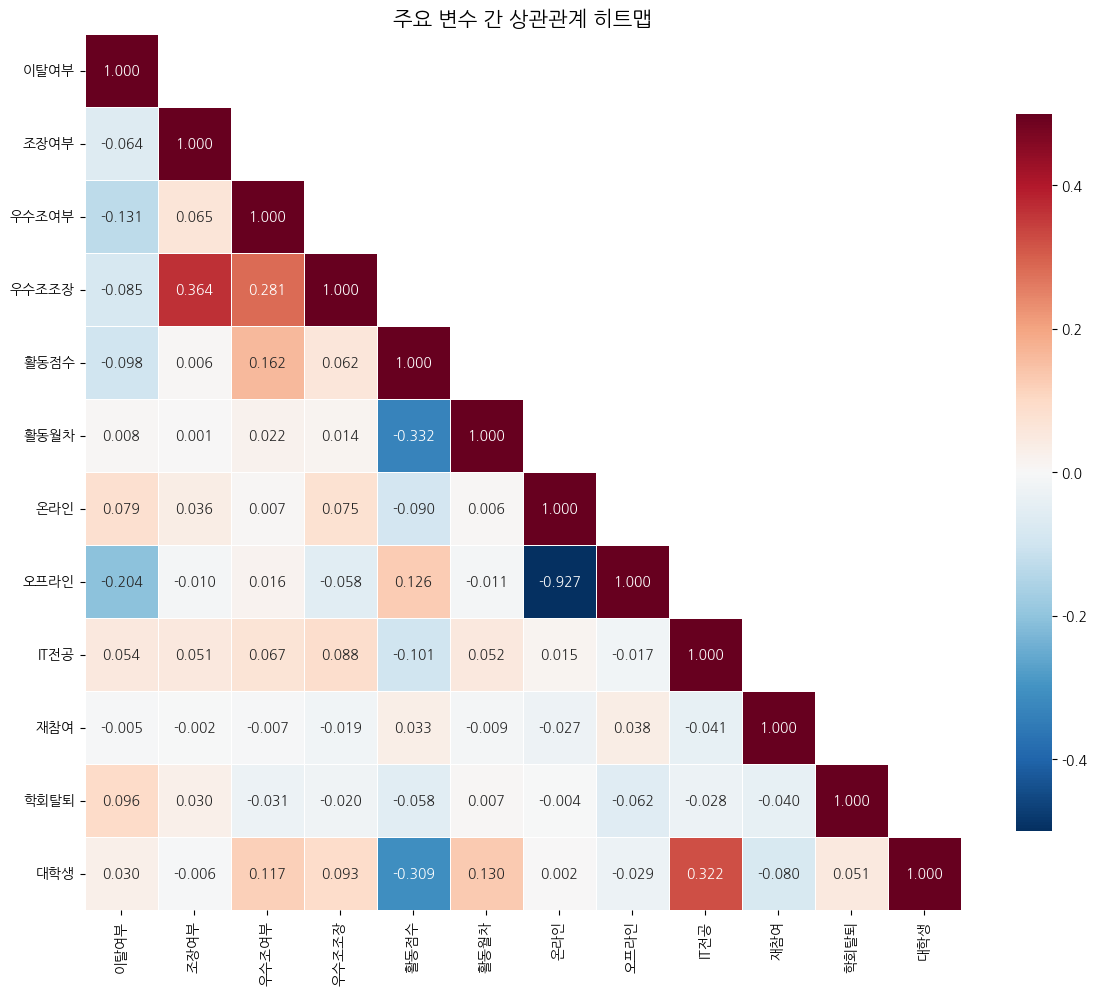

In [7]:
import seaborn as sns

# 분석용 데이터 인코딩
df_corr = pd.DataFrame()
df_corr['이탈여부'] = df_group['leave_flag']
df_corr['조장여부'] = df_group['group_master'].astype(int)
df_corr['우수조여부'] = df_group['excellent_group'].astype(int)
df_corr['우수조조장'] = df_group['excellent_group_master'].astype(bool).astype(int)
df_corr['활동점수'] = df_group['point']
df_corr['활동월차'] = df_group['nth_month']
df_corr['온라인'] = (df_group['on_offline'] == '온라인').astype(int)
df_corr['오프라인'] = (df_group['on_offline'] == '오프라인').astype(int)
df_corr['IT전공'] = (
    df_group['major1_1'].astype(str).str.contains('IT', na=False) |
    df_group['major1_2'].astype(str).str.contains('IT', na=False) |
    df_group['major1_3'].astype(str).str.contains('IT', na=False)
).astype(int)
df_corr['재참여'] = df_group['before_id'].notna().astype(int)
df_corr['학회탈퇴'] = df_group['withdrawal'].astype(int)
df_corr['대학생'] = (df_group['job'] == '대학생').astype(int)

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('주요 변수 간 상관관계 히트맵', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 1) 조별활동 이탈 현황 overview


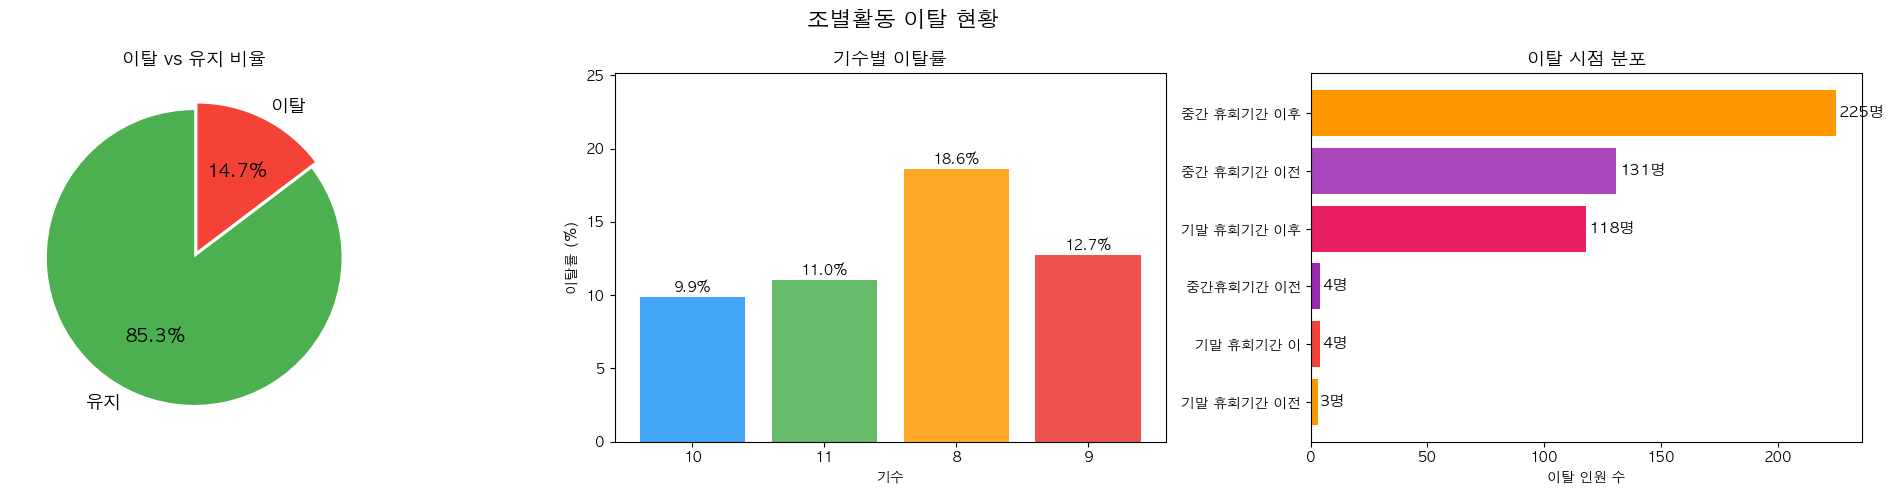

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df_group = df[df['group_leave'].notna()].copy()
df_group['group_leave'] = df_group['group_leave'].astype(bool)
df_group['leave_flag'] = df_group['group_leave'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('조별활동 이탈 현황', fontsize=16, fontweight='bold')

# (1) 파이차트
leave_counts = df_group['group_leave'].value_counts()
axes[0].pie(leave_counts.values, labels=['유지', '이탈'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, textprops={'fontsize': 13}, explode=[0, 0.05])
axes[0].set_title('이탈 vs 유지 비율', fontsize=13, fontweight='bold')

# (2) 기수별 이탈률
gen = df_group.groupby('generation')['leave_flag'].agg(['mean', 'count'])
bars = axes[1].bar(gen.index.astype(str), gen['mean'] * 100,
                   color=['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
axes[1].set_xlabel('기수'); axes[1].set_ylabel('이탈률 (%)')
axes[1].set_title('기수별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, gen['mean'], gen['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=10)
axes[1].set_ylim(0, gen['mean'].max() * 100 * 1.35)

# (3) 이탈 시점 분포
timing = df_group[df_group['group_leave'] == True]['leave_point'].value_counts()
timing = timing[~timing.index.isin(['해당없음', '확인 불가'])]
timing = timing.sort_values(ascending=True)
bars = axes[2].barh(timing.index, timing.values,
                    color=['#FF9800', '#F44336', '#9C27B0', '#E91E63', '#AB47BC'][:len(timing)])
axes[2].set_xlabel('이탈 인원 수')
axes[2].set_title('이탈 시점 분포', fontsize=13, fontweight='bold')
for i, val in enumerate(timing.values):
    axes[2].text(val + 1, i, f'{val}명', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("overview1.png", dpi=300, bbox_inches="tight")
plt.show()

### 2) 개인 특성별 이탈률(IT전공, 직업, 재참여 여부)

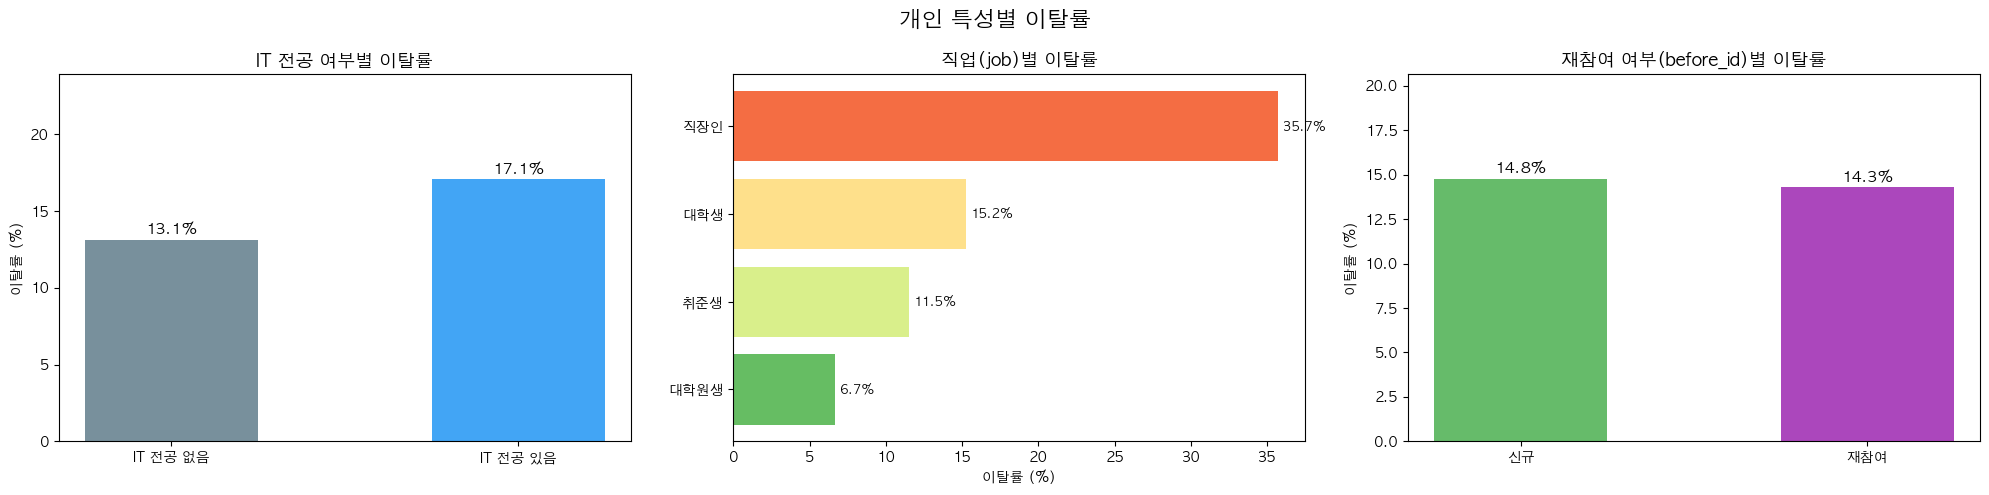

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('개인 특성별 이탈률', fontsize=16, fontweight='bold')

# (1) IT 전공 여부
df_group['has_IT'] = (
    df_group['major1_1'].astype(str).str.contains('IT', na=False) |
    df_group['major1_2'].astype(str).str.contains('IT', na=False) |
    df_group['major1_3'].astype(str).str.contains('IT', na=False)
)
it_leave = df_group.groupby('has_IT')['leave_flag'].agg(['mean', 'count'])
it_leave.index = ['IT 전공 없음', 'IT 전공 있음']
bars = axes[0].bar(it_leave.index, it_leave['mean'] * 100, color=['#78909C', '#42A5F5'], width=0.5)
axes[0].set_ylabel('이탈률 (%)')
axes[0].set_title('IT 전공 여부별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, it_leave['mean'], it_leave['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[0].set_ylim(0, it_leave['mean'].max() * 100 * 1.4)

# (2) 직업별 이탈률
job_leave = df_group[df_group['job'].notna()].groupby('job')['leave_flag'].agg(['mean', 'count'])
job_leave = job_leave[job_leave['count'] >= 5].sort_values('mean', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(job_leave)))
bars = axes[1].barh(job_leave.index, job_leave['mean'] * 100, color=colors)
axes[1].set_xlabel('이탈률 (%)')
axes[1].set_title('직업(job)별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, job_leave['mean'], job_leave['count']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2.,
                 f'{rate*100:.1f}%', va='center', fontsize=9)

# (3) 재참여 여부
df_group['has_before'] = df_group['before_id'].notna()
before_leave = df_group.groupby('has_before')['leave_flag'].agg(['mean', 'count'])
before_leave.index = ['신규', '재참여']
bars = axes[2].bar(before_leave.index, before_leave['mean'] * 100, color=['#66BB6A', '#AB47BC'], width=0.5)
axes[2].set_ylabel('이탈률 (%)')
axes[2].set_title('재참여 여부(before_id)별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, before_leave['mean'], before_leave['count']):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[2].set_ylim(0, before_leave['mean'].max() * 100 * 1.4)

plt.tight_layout()
plt.savefig("overview2.png", dpi=300, bbox_inches="tight")
plt.show()

### 3) 소속/활동별 이탈률 (학회 탈퇴, 온라인/오프라인)

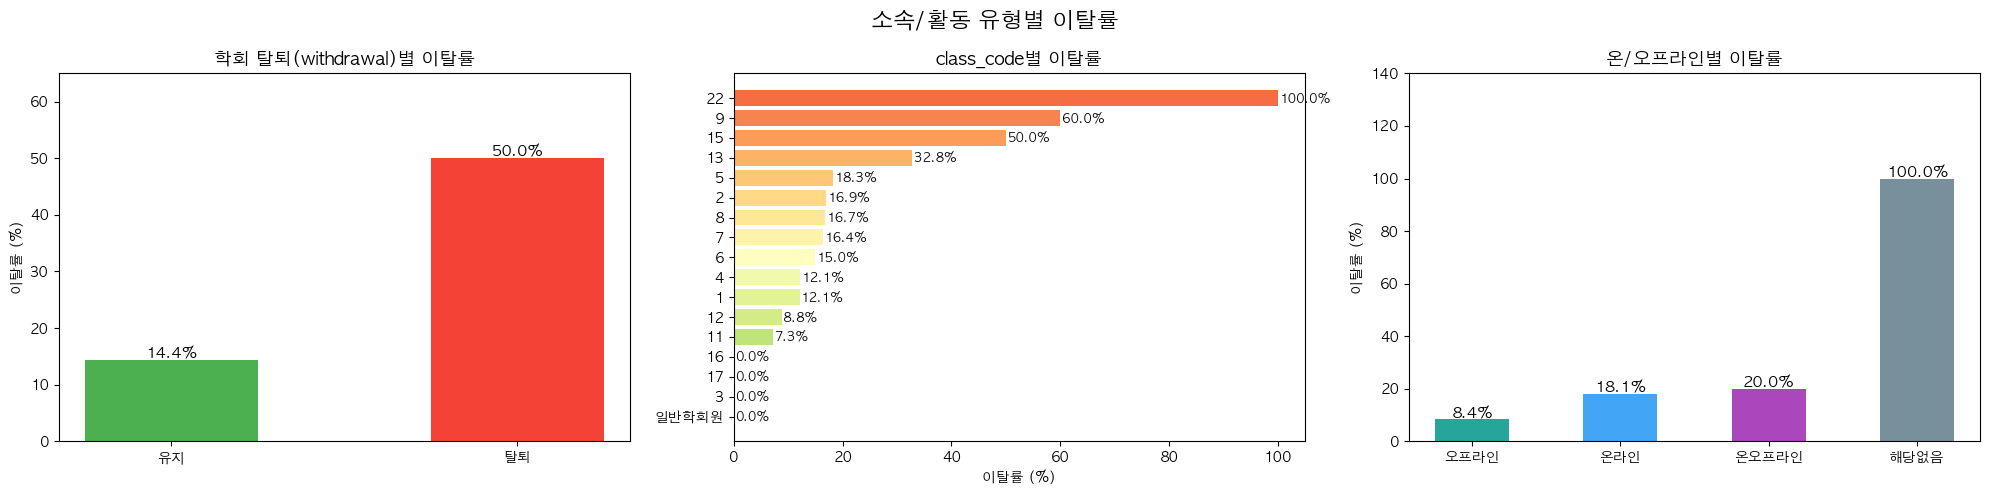

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('소속/활동 유형별 이탈률', fontsize=16, fontweight='bold')

# (1) withdrawal
wd_leave = df_group.groupby(df_group['withdrawal'].astype(bool))['leave_flag'].agg(['mean', 'count'])
wd_leave.index = ['유지', '탈퇴']
bars = axes[0].bar(wd_leave.index, wd_leave['mean'] * 100, color=['#4CAF50', '#F44336'], width=0.5)
axes[0].set_ylabel('이탈률 (%)')
axes[0].set_title('학회 탈퇴(withdrawal)별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, wd_leave['mean'], wd_leave['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[0].set_ylim(0, wd_leave['mean'].max() * 100 * 1.3)

# (2) class_code별 이탈률
cc = df_group[df_group['class_code'].notna()].groupby('class_code')['leave_flag'].agg(['mean', 'count'])
cc = cc[cc['count'] >= 5].sort_values('mean', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cc)))
bars = axes[1].barh(cc.index.astype(str), cc['mean'] * 100, color=colors)
axes[1].set_xlabel('이탈률 (%)')
axes[1].set_title('class_code별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, cc['mean'], cc['count']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2.,
                 f'{rate*100:.1f}%', va='center', fontsize=9)

# (3) 온/오프라인
on_leave = df_group[df_group['on_offline'].notna()].groupby('on_offline')['leave_flag'].agg(['mean', 'count'])
on_leave = on_leave.sort_values('mean')
bars = axes[2].bar(on_leave.index, on_leave['mean'] * 100,
                   color=['#26A69A', '#42A5F5', '#AB47BC', '#78909C'][:len(on_leave)], width=0.5)
axes[2].set_ylabel('이탈률 (%)')
axes[2].set_title('온/오프라인별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, on_leave['mean'], on_leave['count']):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[2].set_ylim(0, on_leave['mean'].max() * 100 * 1.4)

plt.tight_layout()
plt.savefig("overview3.png", dpi=300, bbox_inches="tight")
plt.show()

### 4)  조 역할/성과별 이탈률

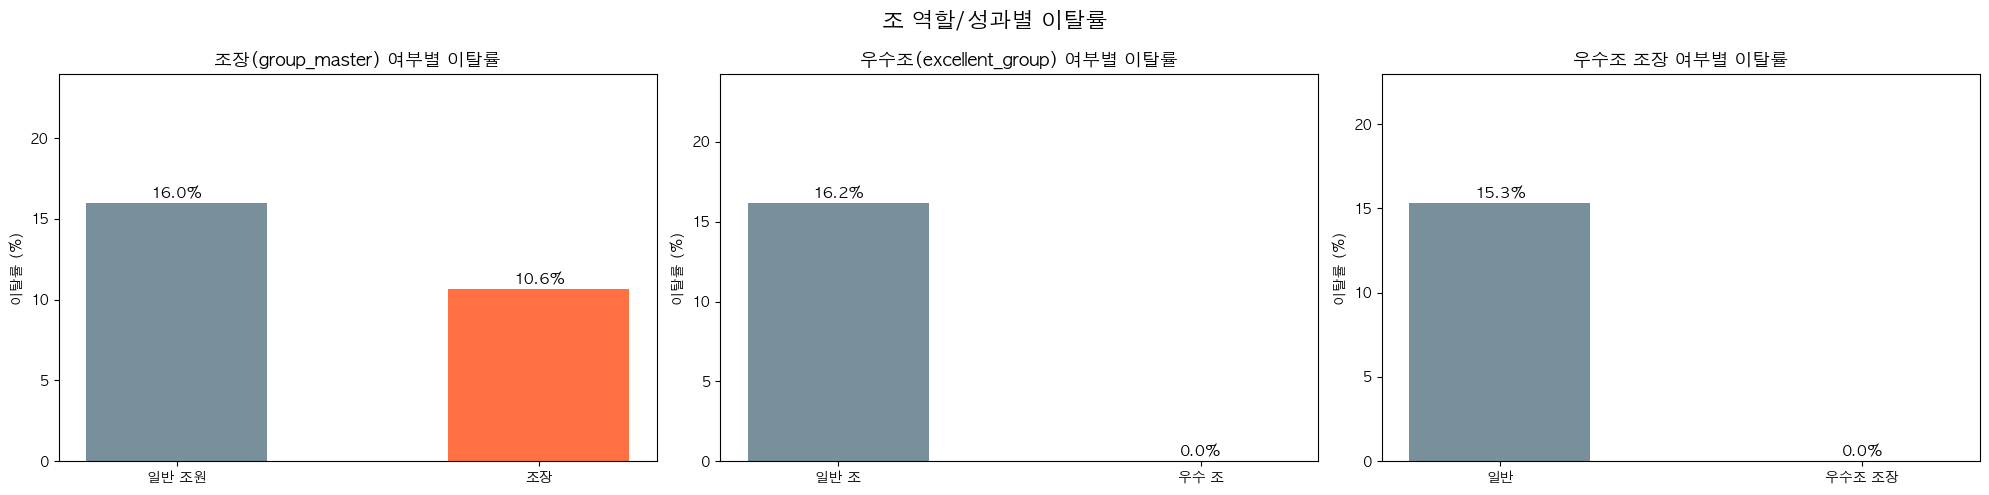

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('조 역할/성과별 이탈률', fontsize=16, fontweight='bold')

# (1) 조장 여부
ml = df_group.groupby('group_master')['leave_flag'].agg(['mean', 'count'])
ml.index = ['일반 조원', '조장']
bars = axes[0].bar(ml.index, ml['mean'] * 100, color=['#78909C', '#FF7043'], width=0.5)
axes[0].set_ylabel('이탈률 (%)')
axes[0].set_title('조장(group_master) 여부별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, ml['mean'], ml['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[0].set_ylim(0, ml['mean'].max() * 100 * 1.5)

# (2) 우수조 여부
el = df_group.groupby('excellent_group')['leave_flag'].agg(['mean', 'count'])
el.index = ['일반 조', '우수 조']
bars = axes[1].bar(el.index, el['mean'] * 100, color=['#78909C', '#66BB6A'], width=0.5)
axes[1].set_ylabel('이탈률 (%)')
axes[1].set_title('우수조(excellent_group) 여부별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, el['mean'], el['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[1].set_ylim(0, el['mean'].max() * 100 * 1.5)

# (3) 우수조 조장 여부
em = df_group.groupby('excellent_group_master')['leave_flag'].agg(['mean', 'count'])
em.index = ['일반', '우수조 조장']
bars = axes[2].bar(em.index, em['mean'] * 100, color=['#78909C', '#FFB74D'], width=0.5)
axes[2].set_ylabel('이탈률 (%)')
axes[2].set_title('우수조 조장 여부별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, em['mean'], em['count']):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=11)
axes[2].set_ylim(0, em['mean'].max() * 100 * 1.5)

plt.tight_layout()
plt.savefig("overview4.png", dpi=300, bbox_inches="tight")
plt.show()

### 5) 활동 점수 및 교차 분석

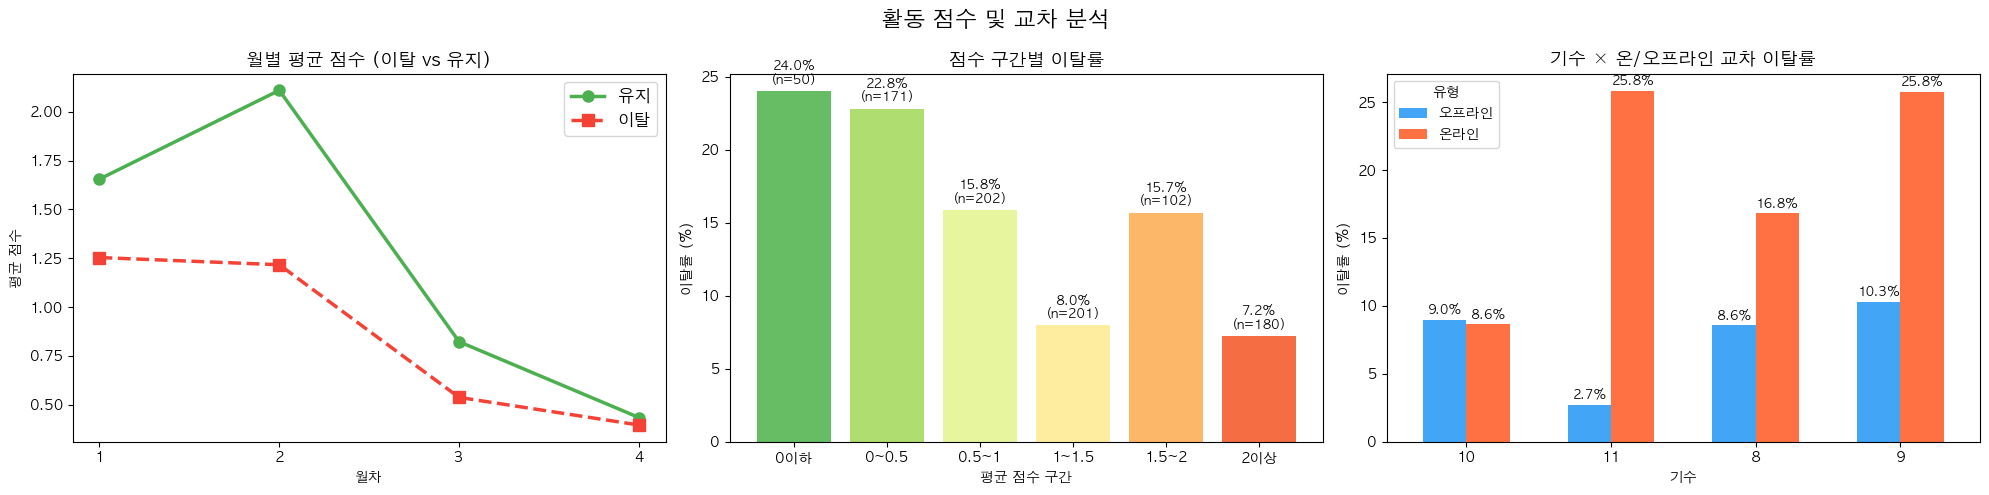

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('활동 점수 및 교차 분석', fontsize=16, fontweight='bold')

# (1) 이탈/유지 월별 평균 점수
df_pt = df_group[df_group['nth_month'].notna() & df_group['point'].notna()]
monthly = df_pt.groupby(['nth_month', 'group_leave'])['point'].mean().reset_index()
mp = monthly.pivot(index='nth_month', columns='group_leave', values='point')
mp.columns = ['유지', '이탈']
axes[0].plot(mp.index, mp['유지'], 'o-', color='#4CAF50', linewidth=2.5, markersize=8, label='유지')
axes[0].plot(mp.index, mp['이탈'], 's--', color='#F44336', linewidth=2.5, markersize=8, label='이탈')
axes[0].set_xlabel('월차'); axes[0].set_ylabel('평균 점수')
axes[0].set_title('월별 평균 점수 (이탈 vs 유지)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12); axes[0].set_xticks(sorted(mp.index))

# (2) 점수 구간별 이탈률
df_wp = df_group[df_group['point'].notna()].copy()
ma = df_wp.groupby(['member_id', 'generation', 'class_code', 'group_number']).agg(
    avg_point=('point', 'mean'), group_leave=('group_leave', 'first')).reset_index()
ma['pg'] = pd.cut(ma['avg_point'], bins=[-2, 0, 0.5, 1.0, 1.5, 2.0, 15],
                   labels=['0이하', '0~0.5', '0.5~1', '1~1.5', '1.5~2', '2이상'])
pl = ma.groupby('pg')['group_leave'].agg(['mean', 'count'])
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(pl)))
bars = axes[1].bar(pl.index.astype(str), pl['mean'] * 100, color=colors)
axes[1].set_xlabel('평균 점수 구간'); axes[1].set_ylabel('이탈률 (%)')
axes[1].set_title('점수 구간별 이탈률', fontsize=13, fontweight='bold')
for bar, rate, cnt in zip(bars, pl['mean'], pl['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{rate*100:.1f}%\n(n={int(cnt)})', ha='center', fontsize=9)

# (3) 기수 × 온오프라인 교차 이탈률
cross = df_group.groupby(['generation', 'on_offline'])['leave_flag'].mean().reset_index()
cross = cross[cross['on_offline'].isin(['온라인', '오프라인'])]
cp = cross.pivot(index='generation', columns='on_offline', values='leave_flag') * 100
cp.plot(kind='bar', ax=axes[2], color=['#42A5F5', '#FF7043'], width=0.6)
axes[2].set_xlabel('기수'); axes[2].set_ylabel('이탈률 (%)')
axes[2].set_title('기수 × 온/오프라인 교차 이탈률', fontsize=13, fontweight='bold')
axes[2].legend(title='유형', fontsize=10); axes[2].tick_params(axis='x', rotation=0)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig("overview5.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. 분류 모델링

### 0) 공통 피처 준비 및 데이터 분리

In [13]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1. 피처 준비 (공통)
df_model = df_group.copy()
df_model['is_online'] = (df_model['on_offline'] == '온라인').astype(int)
df_model['is_offline'] = (df_model['on_offline'] == '오프라인').astype(int)
df_model['has_IT'] = (
    df_model['major1_1'].astype(str).str.contains('IT', na=False) |
    df_model['major1_2'].astype(str).str.contains('IT', na=False) |
    df_model['major1_3'].astype(str).str.contains('IT', na=False)
).astype(int)
df_model['has_before'] = df_model['before_id'].notna().astype(int)
df_model['is_student'] = (df_model['job'] == '대학생').astype(int)
df_model['group_master_int'] = df_model['group_master'].astype(int)
df_model['generation'] = df_model['generation'].astype(int)

# 로지스틱 회귀를 위해 목표 변수도 int 변환 처리
if 'group_leave' in df_model.columns:
    df_model['leave_flag'] = df_model['group_leave'].astype(int)
# 모델 수렴을 방해하는 'excellent_group_int'(우수조여부) 변수 제거
features = ['generation', 'group_master_int', 
            'is_online', 'has_IT', 'has_before',
            'is_student', 'point', 'nth_month' ]
feature_names_kr = ['기수', '조장여부', 
                     '온라인', 'IT전공', '재참여',
                     '대학생', '활동점수', '활동월차']

# 2. 결측치 제거 및 x, y 지정
df_clean = df_model[features + ['leave_flag']].dropna()
x = df_clean[features].astype(float) 
y = df_clean['leave_flag']
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# 3. 불균형 데이터 처리 비율 계산 (XGBoost용)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(f"전체 학습 데이터: {x_train.shape[0]}건")
print(f"클래스 분포 - 유지: {neg}건, 이탈: {pos}건, 비율: {neg/pos:.1f} : 1.0")

전체 학습 데이터: 2759건
클래스 분포 - 유지: 2366건, 이탈: 393건, 비율: 6.0 : 1.0


### 1) 데이터 전처리(교호작용, 다중공선성 고려)

In [14]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1. 교호작용 파생 변수 생성
x_train_inter = x_train.copy()
x_val_inter = x_val.copy()

is_worker_train = (df_model.loc[x_train.index, 'job'] == '직장인').astype(int)
is_worker_val = (df_model.loc[x_val.index, 'job'] == '직장인').astype(int)

x_train_inter['온라인_x_대학생'] = x_train_inter['is_online'] * x_train_inter['is_student']
x_train_inter['조장_x_직장인'] = x_train_inter['group_master_int'] * is_worker_train
x_train_inter['재참여_x_온라인'] = x_train_inter['has_before'] * x_train_inter['is_online']
x_val_inter['온라인_x_대학생'] = x_val_inter['is_online'] * x_val_inter['is_student']
x_val_inter['조장_x_직장인'] = x_val_inter['group_master_int'] * is_worker_val
x_val_inter['재참여_x_온라인'] = x_val_inter['has_before'] * x_val_inter['is_online']

x_train_sm = sm.add_constant(x_train_inter)
x_val_sm = sm.add_constant(x_val_inter)

feature_names_inter = ['const'] + feature_names_kr + ['온라인_x_대학생', '조장_x_직장인', '재참여_x_온라인']
x_train_sm.columns = feature_names_inter
x_val_sm.columns = feature_names_inter

# 2. 다중공선성 (VIF) 확인
print("=== [VIF (다중공선성) 지수 확인] ===")
print("VIF가 10 이상이면 다른 변수와 특성이 너무 겹친다는 뜻입니다.")
vif_data = pd.DataFrame()
vif_data["변수"] = x_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(x_train_sm.values, i) for i in range(x_train_sm.shape[1])]
display(vif_data[vif_data['변수'] != 'const'].sort_values('VIF', ascending=False))

=== [VIF (다중공선성) 지수 확인] ===
VIF가 10 이상이면 다른 변수와 특성이 너무 겹친다는 뜻입니다.


,변수,VIF
9,온라인_x_대학생,5.591006
3,온라인,5.316449
6,대학생,2.661308
1,기수,2.109853
11,재참여_x_온라인,1.771551
5,재참여,1.618101
7,활동점수,1.270385
4,IT전공,1.269665
8,활동월차,1.129080
10,조장_x_직장인,1.062337


### 2) RF, XGB 기반 변수 중요도 시각화

In [20]:
# ──────────────────────────────────────────────
# 1. Random Forest 하이퍼파라미터 튜닝 (Optuna)
# ──────────────────────────────────────────────
print("▶ Random Forest 튜닝 중 (Optuna)...")
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42,
        'class_weight': 'balanced',
        'n_jobs': -1
    }
    if trial.suggest_categorical('max_depth_none', [True, False]):
        params['max_depth'] = None
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, x_train_sm, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()
rf_study = optuna.create_study(direction='maximize', study_name='RF')
rf_study.optimize(rf_objective, n_trials=150, show_progress_bar=True)

# 최적 파라미터로 모델 재학습
rf_best_params = rf_study.best_params.copy()
if rf_best_params.pop('max_depth_none', False):
    rf_best_params['max_depth'] = None
rf_best = RandomForestClassifier(
    **rf_best_params,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_best.fit(x_train_sm, y_train)
print(f"RF 최적 파라미터: {rf_best_params}")
print(f"RF 최적 F1 Score (CV): {rf_study.best_value:.4f}")

# ──────────────────────────────────────────────
# 2. XGBoost 하이퍼파라미터 튜닝 (Optuna)
# ──────────────────────────────────────────────
print("\n▶ XGBoost 튜닝 중 (Optuna)...")
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0,
        'n_jobs': -1
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, x_train_sm, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()
xgb_study = optuna.create_study(direction='maximize', study_name='XGB')
xgb_study.optimize(xgb_objective, n_trials=200, show_progress_bar=True)

# 최적 파라미터로 모델 재학습
xgb_best_params = xgb_study.best_params.copy()
xgb_best = XGBClassifier(
    **xgb_best_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_best.fit(x_train_sm, y_train)
print(f"XGB 최적 파라미터: {xgb_best_params}")
print(f"XGB 최적 F1 Score (CV): {xgb_study.best_value:.4f}")

# ──────────────────────────────────────────────
# 3. 앙상블 변수 중요도 랭킹
# ──────────────────────────────────────────────
fs_df = pd.DataFrame({
    '변수': x_train_sm.columns
})
fs_df['RF_Score'] = rf_best.feature_importances_
fs_df['RF_Rank'] = fs_df['RF_Score'].rank(ascending=False, method='min')
fs_df['XGB_Score'] = xgb_best.feature_importances_
fs_df['XGB_Rank'] = fs_df['XGB_Score'].rank(ascending=False, method='min')

fs_df['Ensemble_Rank'] = (fs_df['RF_Rank'] + fs_df['XGB_Rank']) / 2.0
fs_df = fs_df.sort_values(by='Ensemble_Rank', ascending=True)
print("\n=== [앙상블 변수 중요도 랭킹 (RF + XGB 최적모델)] ===")
display(fs_df)

top_n = 7
selected_features = fs_df[
    (fs_df['변수'] != 'const') & 
    (fs_df['변수'] != '오프라인')
]['변수'].head(top_n).tolist()
print(f"\n1차 필터링 통과한 Top {top_n} 변수 목록: {selected_features}")
# 선택된 변수만으로 학습 데이터셋 구성
x_train_selected = x_train_sm[['const'] + selected_features]
x_val_selected = x_val_sm[['const'] + selected_features]

▶ Random Forest 튜닝 중 (Optuna)...


  0%|          | 0/150 [00:00<?, ?it/s]

RF 최적 파라미터: {'n_estimators': 173, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 4}
RF 최적 F1 Score (CV): 0.3714

▶ XGBoost 튜닝 중 (Optuna)...


  0%|          | 0/200 [00:00<?, ?it/s]

XGB 최적 파라미터: {'n_estimators': 114, 'max_depth': 10, 'learning_rate': 0.17803465307312696, 'subsample': 0.6446310780383373, 'colsample_bytree': 0.953143901352192, 'min_child_weight': 1, 'gamma': 0.029655397657258567, 'reg_alpha': 0.00018715297436926726, 'reg_lambda': 3.0915730343185877e-06}
XGB 최적 F1 Score (CV): 0.2457

=== [앙상블 변수 중요도 랭킹 (RF + XGB 최적모델)] ===


,변수,RF_Score,RF_Rank,XGB_Score,XGB_Rank,Ensemble_Rank
7,활동점수,0.411766,1.0,0.117833,2.0,1.5
1,기수,0.149855,2.0,0.105817,3.0,2.5
2,조장여부,0.085202,4.0,0.102579,5.0,4.5
5,재참여,0.049266,7.0,0.104146,4.0,5.5
11,재참여_x_온라인,0.024265,10.0,0.124833,1.0,5.5
3,온라인,0.066774,5.0,0.087112,8.0,6.5
4,IT전공,0.055746,6.0,0.088987,7.0,6.5
8,활동월차,0.092427,3.0,0.081060,10.0,6.5
6,대학생,0.032327,8.0,0.101964,6.0,7.0
9,온라인_x_대학생,0.030223,9.0,0.085669,9.0,9.0



1차 필터링 통과한 Top 7 변수 목록: ['활동점수', '기수', '조장여부', '재참여', '재참여_x_온라인', '온라인', 'IT전공']


### 3) 로지스틱 회귀 분석

In [25]:
classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

print("▶ 이탈 원인 분석 (로지스틱 회귀 검증)")
sm_model = sm.Logit(y_train.values, x_train_selected)
result = sm_model.fit(disp=False) 

print("\n=== [로지스틱 회귀 전체 결과 요약포] ===")
display(result.summary())

summary_df = pd.DataFrame({
    '변수': x_train_selected.columns,
    '회귀계수(Coefficient)': result.params.values,
    'p-value': result.pvalues.values,
    '오즈비(Odds Ratio)': np.exp(result.params.values)
})
significant_vars = summary_df[(summary_df['p-value'] < 0.05) & (summary_df['변수'] != 'const')].sort_values(by='오즈비(Odds Ratio)', ascending=False)
display(significant_vars)

print("\n▶ 이탈 확률 예측 및 성능 평가 ")
# 전체 변수를 유지한 모델로 확률 예측
y_pred_prob_xgb = xgb_best.predict_proba(x_val_sm)[:, 1]
# ★ Precision과 Recall의 균형을 맞추는 최적의 Threshold 찾기
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_prob_xgb)
# F1-score가 최대가 되는 지점을 최적 Threshold로 선정
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) 
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
# 최적 Threshold 적용
y_pred_best = (y_pred_prob_xgb >= best_threshold).astype(int)
print(f"\n=== [데이터 맞춤형 최적의 Threshold ({best_threshold:.3f}) 적용] ===")
print("XGBoost 앙상블로 이탈자를 집중 분석했습니다.")
print(classification_report(y_val, y_pred_best, target_names=['유지', '이탈']))
cm = confusion_matrix(y_val, y_pred_best)
print(f"Confusion Matrix (최적 기준):\n[진짜 유지(TN): {cm[0][0]}, 가짜 이탈경고(FP): {cm[0][1]}]\n[놓친 이탈자(FN): {cm[1][0]}, 찾아낸 이탈자(TP): {cm[1][1]}]")
roc_auc = roc_auc_score(y_val, y_pred_prob_xgb)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


▶ 이탈 원인 분석 (로지스틱 회귀 검증)

=== [로지스틱 회귀 전체 결과 요약포] ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2759
Model:                          Logit   Df Residuals:                     2751
Method:                           MLE   Df Model:                            7
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                 0.03535
Time:                        22:30:13   Log-Likelihood:                -1089.5
converged:                       True   LL-Null:                       -1129.5
Covariance Type:            nonrobust   LLR p-value:                 1.481e-14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2379      0.602     -0.395      0.693      -1.418       0.942
활동점수          -0.2334      0.049     -4.788      0.000      -0.329      -0.138
기수            -0.1596      0.064     -2.500      0.012      -0.285      -0.034
조장여부          -0.5273      0.143     -3.679      0.000      -0.808      -0.246
재참여           -0.2903      0.231     -1.257      0.209      -0.743       0.162
재참여_x_온라인      0.5230      0.322      1.624      0.104      -0.108       1.154
온라인            0.2934      0.121      2.420      0.016       0.056       0.531
IT전공           0.2167      0.123      1.764      0.078      -0.024       0.458
==============================================================================
"""

,변수,회귀계수(Coefficient),p-value,오즈비(Odds Ratio)
6,온라인,0.293410,0.015541,1.340993
2,기수,-0.159632,0.012409,0.852458
1,활동점수,-0.233364,0.000002,0.791866
3,조장여부,-0.527311,0.000234,0.590190



▶ 이탈 확률 예측 및 성능 평가 

=== [데이터 맞춤형 최적의 Threshold (0.293) 적용] ===
XGBoost 앙상블로 이탈자를 집중 분석했습니다.
              precision    recall  f1-score   support

          유지       0.90      0.88      0.89       592
          이탈       0.37      0.44      0.40        98

    accuracy                           0.81       690
   macro avg       0.64      0.66      0.65       690
weighted avg       0.83      0.81      0.82       690

Confusion Matrix (최적 기준):
[진짜 유지(TN): 519, 가짜 이탈경고(FP): 73]
[놓친 이탈자(FN): 55, 찾아낸 이탈자(TP): 43]

ROC-AUC Score: 0.7061


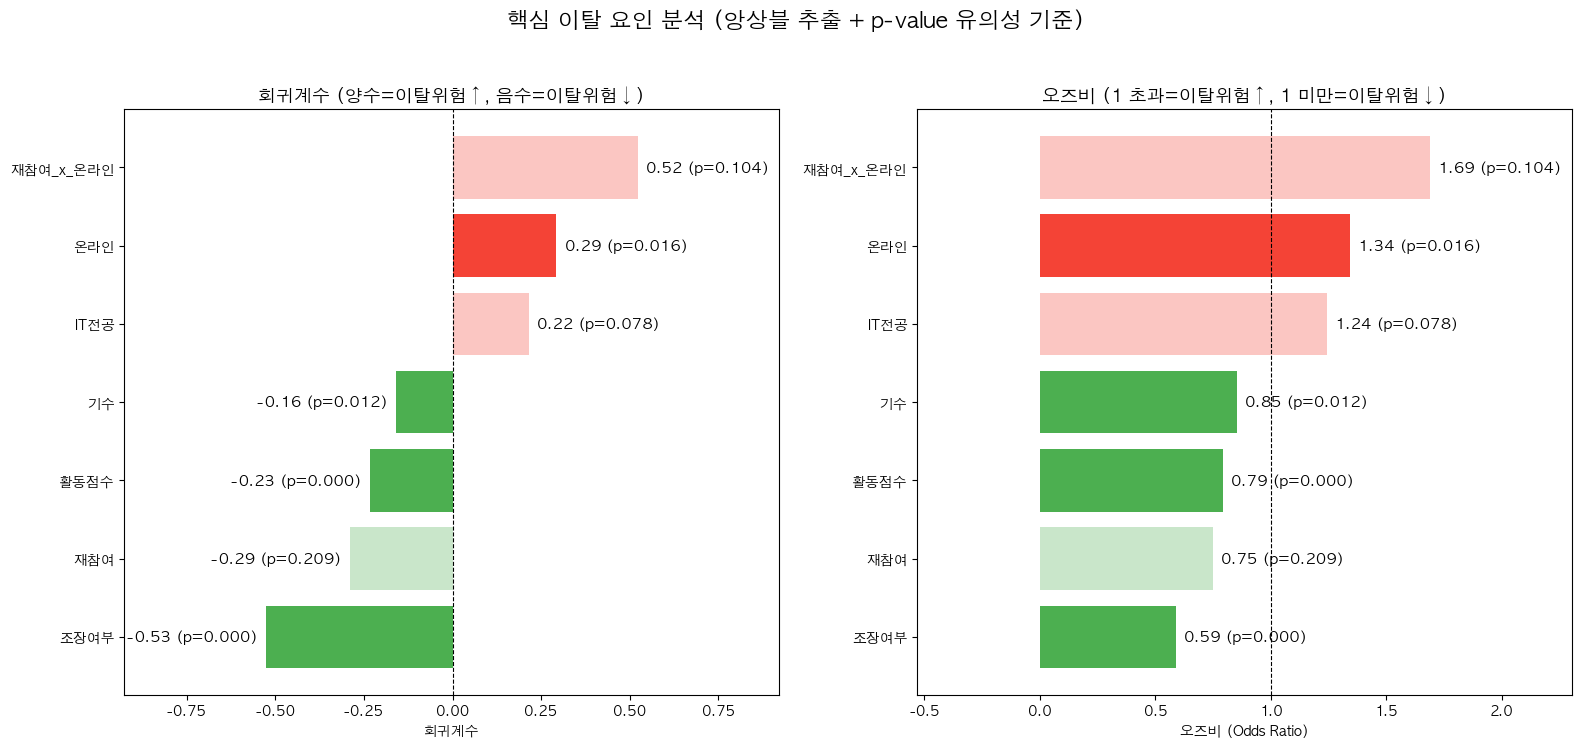


=== 핵심 분석 결론 (유의미한 요인 위주) ===
🚨 온라인: 오즈비 1.34배 → [이탈 위험을 증가시키는 요인]
 기수: 오즈비 0.85배 → [이탈 방지 등 보호 효과가 있는 요인]
 활동점수: 오즈비 0.79배 → [이탈 방지 등 보호 효과가 있는 요인]
 조장여부: 오즈비 0.59배 → [이탈 방지 등 보호 효과가 있는 요인]


In [26]:
# 요약 결과에서 데이터프레임 추출 
res_df = summary_df[summary_df['변수'] != 'const'].copy()
res_df = res_df.sort_values('오즈비(Odds Ratio)', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('핵심 이탈 요인 분석 (앙상블 추출 + p-value 유의성 기준)', fontsize=16, fontweight='bold')
alphas = [1.0 if p < 0.05 else 0.3 for p in res_df['p-value']]

# (1) 회귀 계수 그래프
colors1 = ['#F44336' if c > 0 else '#4CAF50' for c in res_df['회귀계수(Coefficient)']]
bars1 = axes[0].barh(res_df['변수'], res_df['회귀계수(Coefficient)'], color=colors1)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('회귀계수')
axes[0].set_title('회귀계수 (양수=이탈위험↑, 음수=이탈위험↓)', fontsize=13, fontweight='bold')

x_min, x_max = axes[0].get_xlim()
offset1 = (x_max - x_min) * 0.02
axes[0].set_xlim(x_min - offset1*15, x_max + offset1*15)

for i, (bar, param, p_val) in enumerate(zip(bars1, res_df['회귀계수(Coefficient)'], res_df['p-value'])):
    bar.set_alpha(alphas[i])
    font_weight = 'bold' if p_val < 0.05 else 'normal'
    
    if param >= 0:
        axes[0].text(param + offset1, i, f'{param:.2f} (p={p_val:.3f})', va='center', ha='left', fontsize=11, fontweight=font_weight, color='black')
    else:
        axes[0].text(param - offset1, i, f'{param:.2f} (p={p_val:.3f})', va='center', ha='right', fontsize=11, fontweight=font_weight, color='black')
        
# (2) 오즈비 그래프
colors2 = ['#F44336' if o > 1 else '#4CAF50' for o in res_df['오즈비(Odds Ratio)']]
bars2 = axes[1].barh(res_df['변수'], res_df['오즈비(Odds Ratio)'], color=colors2)
axes[1].axvline(x=1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('오즈비 (Odds Ratio)')
axes[1].set_title('오즈비 (1 초과=이탈위험↑, 1 미만=이탈위험↓)', fontsize=13, fontweight='bold')
x_min2, x_max2 = axes[1].get_xlim()
offset2 = (x_max2 - x_min2) * 0.02
axes[1].set_xlim(x_min2 - offset2*15, x_max2 + offset2*15)
for i, (bar, odds, p_val) in enumerate(zip(bars2, res_df['오즈비(Odds Ratio)'], res_df['p-value'])):
    bar.set_alpha(alphas[i])
    font_weight = 'bold' if p_val < 0.05 else 'normal'
    
    axes[1].text(odds + offset2, i, f'{odds:.2f} (p={p_val:.3f})', va='center', ha='left', fontsize=11, fontweight=font_weight, color='black')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('churn_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 인사이트 정리 출력 ---
print("\n=== 핵심 분석 결론 (유의미한 요인 위주) ===")
sig_df = res_df[res_df['p-value'] < 0.05].sort_values('오즈비(Odds Ratio)', ascending=False)
for _, row in sig_df.iterrows():
    if row['오즈비(Odds Ratio)'] > 1:
        print(f"🚨 {row['변수']}: 오즈비 {row['오즈비(Odds Ratio)']:.2f}배 → [이탈 위험을 증가시키는 요인]")
    else:
        print(f" {row['변수']}: 오즈비 {row['오즈비(Odds Ratio)']:.2f}배 → [이탈 방지 등 보호 효과가 있는 요인]")


### 4. 군집분석 (K-means) - 회원 유형 분류

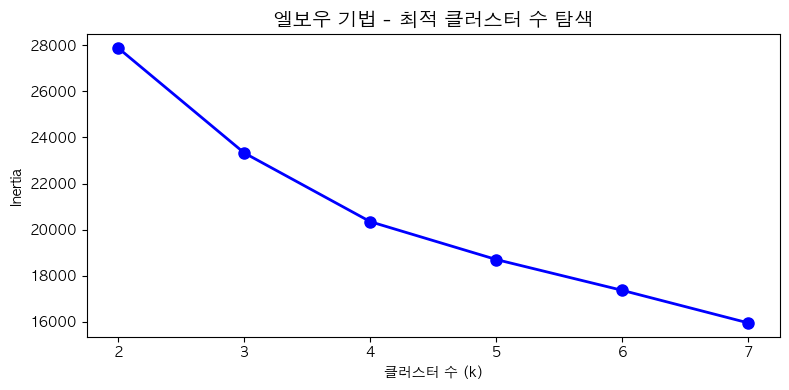

In [27]:
# 피처 준비
df_model = df_group.copy()
df_model['generation'] = df_model['generation'].astype(int)
df_model['is_online'] = (df_model['on_offline'] == '온라인').astype(int)
df_model['is_offline'] = (df_model['on_offline'] == '오프라인').astype(int)
df_model['has_IT'] = (
    df_model['major1_1'].astype(str).str.contains('IT', na=False) |
    df_model['major1_2'].astype(str).str.contains('IT', na=False) |
    df_model['major1_3'].astype(str).str.contains('IT', na=False)
).astype(int)
df_model['has_before'] = df_model['before_id'].notna().astype(int)
df_model['is_student'] = (df_model['job'] == '대학생').astype(int)
df_model['group_master_int'] = df_model['group_master'].astype(int)
df_model['excellent_group_int'] = df_model['excellent_group'].astype(int)
df_model['leave_flag'] = df_model['group_leave'].astype(int)

features = ['generation', 'group_master_int', 'excellent_group_int',
            'is_online', 'is_offline', 'has_IT', 'has_before',
            'is_student', 'point', 'nth_month']

feature_names_kr = ['기수', '조장여부', '우수조여부',
                     '온라인', '오프라인', 'IT전공', '재참여',
                     '대학생', '활동점수', '활동월차']

df_clean = df_model[features + ['leave_flag']].dropna()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_clean[features])

# 최적 클러스터 수 찾기 (엘보우 기법)
inertias = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('클러스터 수 (k)')
ax.set_ylabel('Inertia')
ax.set_title('엘보우 기법 - 최적 클러스터 수 탐색', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

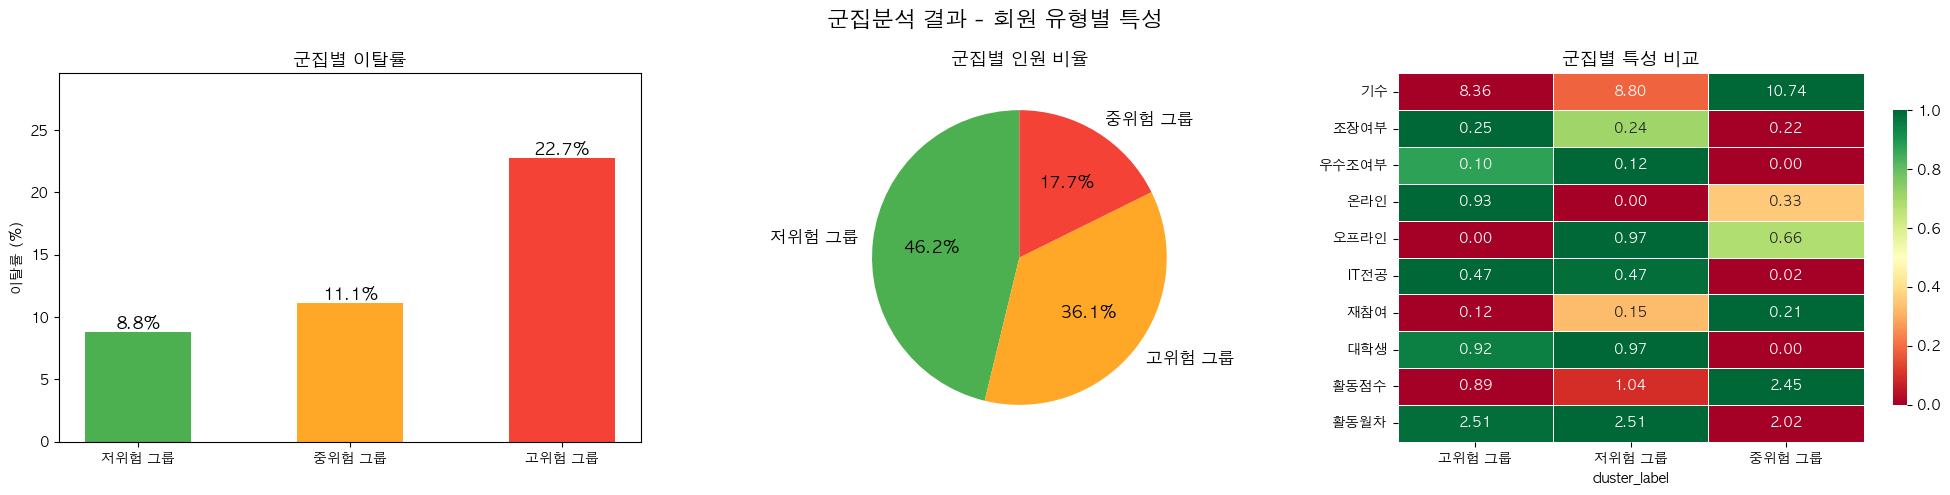


=== 군집별 상세 특성 ===

📌 저위험 그룹 (n=1594, 이탈률: 8.8%)
   기수: 8.80
   조장여부: 0.24
   우수조여부: 0.12
   온라인: 0.00
   오프라인: 0.97
   IT전공: 0.47
   재참여: 0.15
   대학생: 0.97
   활동점수: 1.04
   활동월차: 2.51

📌 중위험 그룹 (n=610, 이탈률: 11.1%)
   기수: 10.74
   조장여부: 0.22
   우수조여부: 0.00
   온라인: 0.33
   오프라인: 0.66
   IT전공: 0.02
   재참여: 0.21
   대학생: 0.00
   활동점수: 2.45
   활동월차: 2.02

📌 고위험 그룹 (n=1245, 이탈률: 22.7%)
   기수: 8.36
   조장여부: 0.25
   우수조여부: 0.10
   온라인: 0.93
   오프라인: 0.00
   IT전공: 0.47
   재참여: 0.12
   대학생: 0.92
   활동점수: 0.89
   활동월차: 2.51


In [28]:
# K-Means 군집화 (k=3: 저위험/중위험/고위험)
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['cluster'] = km.fit_predict(x_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('군집분석 결과 - 회원 유형별 특성', fontsize=16, fontweight='bold')

# (1) 군집별 이탈률
cluster_leave = df_clean.groupby('cluster')['leave_flag'].agg(['mean', 'count'])
cluster_leave = cluster_leave.sort_values('mean')

label_map = {}
for i, idx in enumerate(cluster_leave.index):
    if i == 0:
        label_map[idx] = '저위험 그룹'
    elif i == 1:
        label_map[idx] = '중위험 그룹'
    else:
        label_map[idx] = '고위험 그룹'

cluster_leave.index = [label_map[i] for i in cluster_leave.index]
colors = ['#4CAF50', '#FFA726', '#F44336']
bars = axes[0].bar(cluster_leave.index, cluster_leave['mean'] * 100, color=colors, width=0.5)
axes[0].set_ylabel('이탈률 (%)')
axes[0].set_title('군집별 이탈률', fontsize=13, fontweight='bold')
for bar, rate in zip(bars, cluster_leave['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{rate*100:.1f}%', ha='center', fontsize=12)
axes[0].set_ylim(0, cluster_leave['mean'].max() * 100 * 1.3)

# (2) 군집별 인원 비율
df_clean['cluster_label'] = df_clean['cluster'].map(label_map)
cluster_size = df_clean['cluster_label'].value_counts()
axes[1].pie(cluster_size.values, labels=cluster_size.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('군집별 인원 비율', fontsize=13, fontweight='bold')

# (3) 군집별 주요 특성 비교
cluster_means = df_clean.groupby('cluster_label')[features].mean()
cluster_means.columns = feature_names_kr

cluster_means = cluster_means.astype(float)
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_norm = cluster_norm.astype(float)

import seaborn as sns
sns.heatmap(cluster_norm.T, annot=cluster_means.T.round(2).astype(float).values,
            fmt='.2f', cmap='RdYlGn', ax=axes[2],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[2].set_title('군집별 특성 비교', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== 군집별 상세 특성 ===")
for label in ['저위험 그룹', '중위험 그룹', '고위험 그룹']:
    grp = df_clean[df_clean['cluster_label'] == label]
    print(f"\n📌 {label} (n={len(grp)}, 이탈률: {grp['leave_flag'].mean()*100:.1f}%)")
    for feat, feat_kr in zip(features, feature_names_kr):
        print(f"   {feat_kr}: {grp[feat].mean():.2f}")